In [173]:
"""
Explore Frequency Domain of Events serperated by sample interval...
"""

'\nExplore Frequency Domain of Events serperated by sample interval...\n'

In [174]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from copy import deepcopy

from util.DataGen import nai_pulse, plastic_pulse, sample_shift_to_phase_shift, continuous_time_trace
from util.Processing import threshold_nnlsr_deconvolve

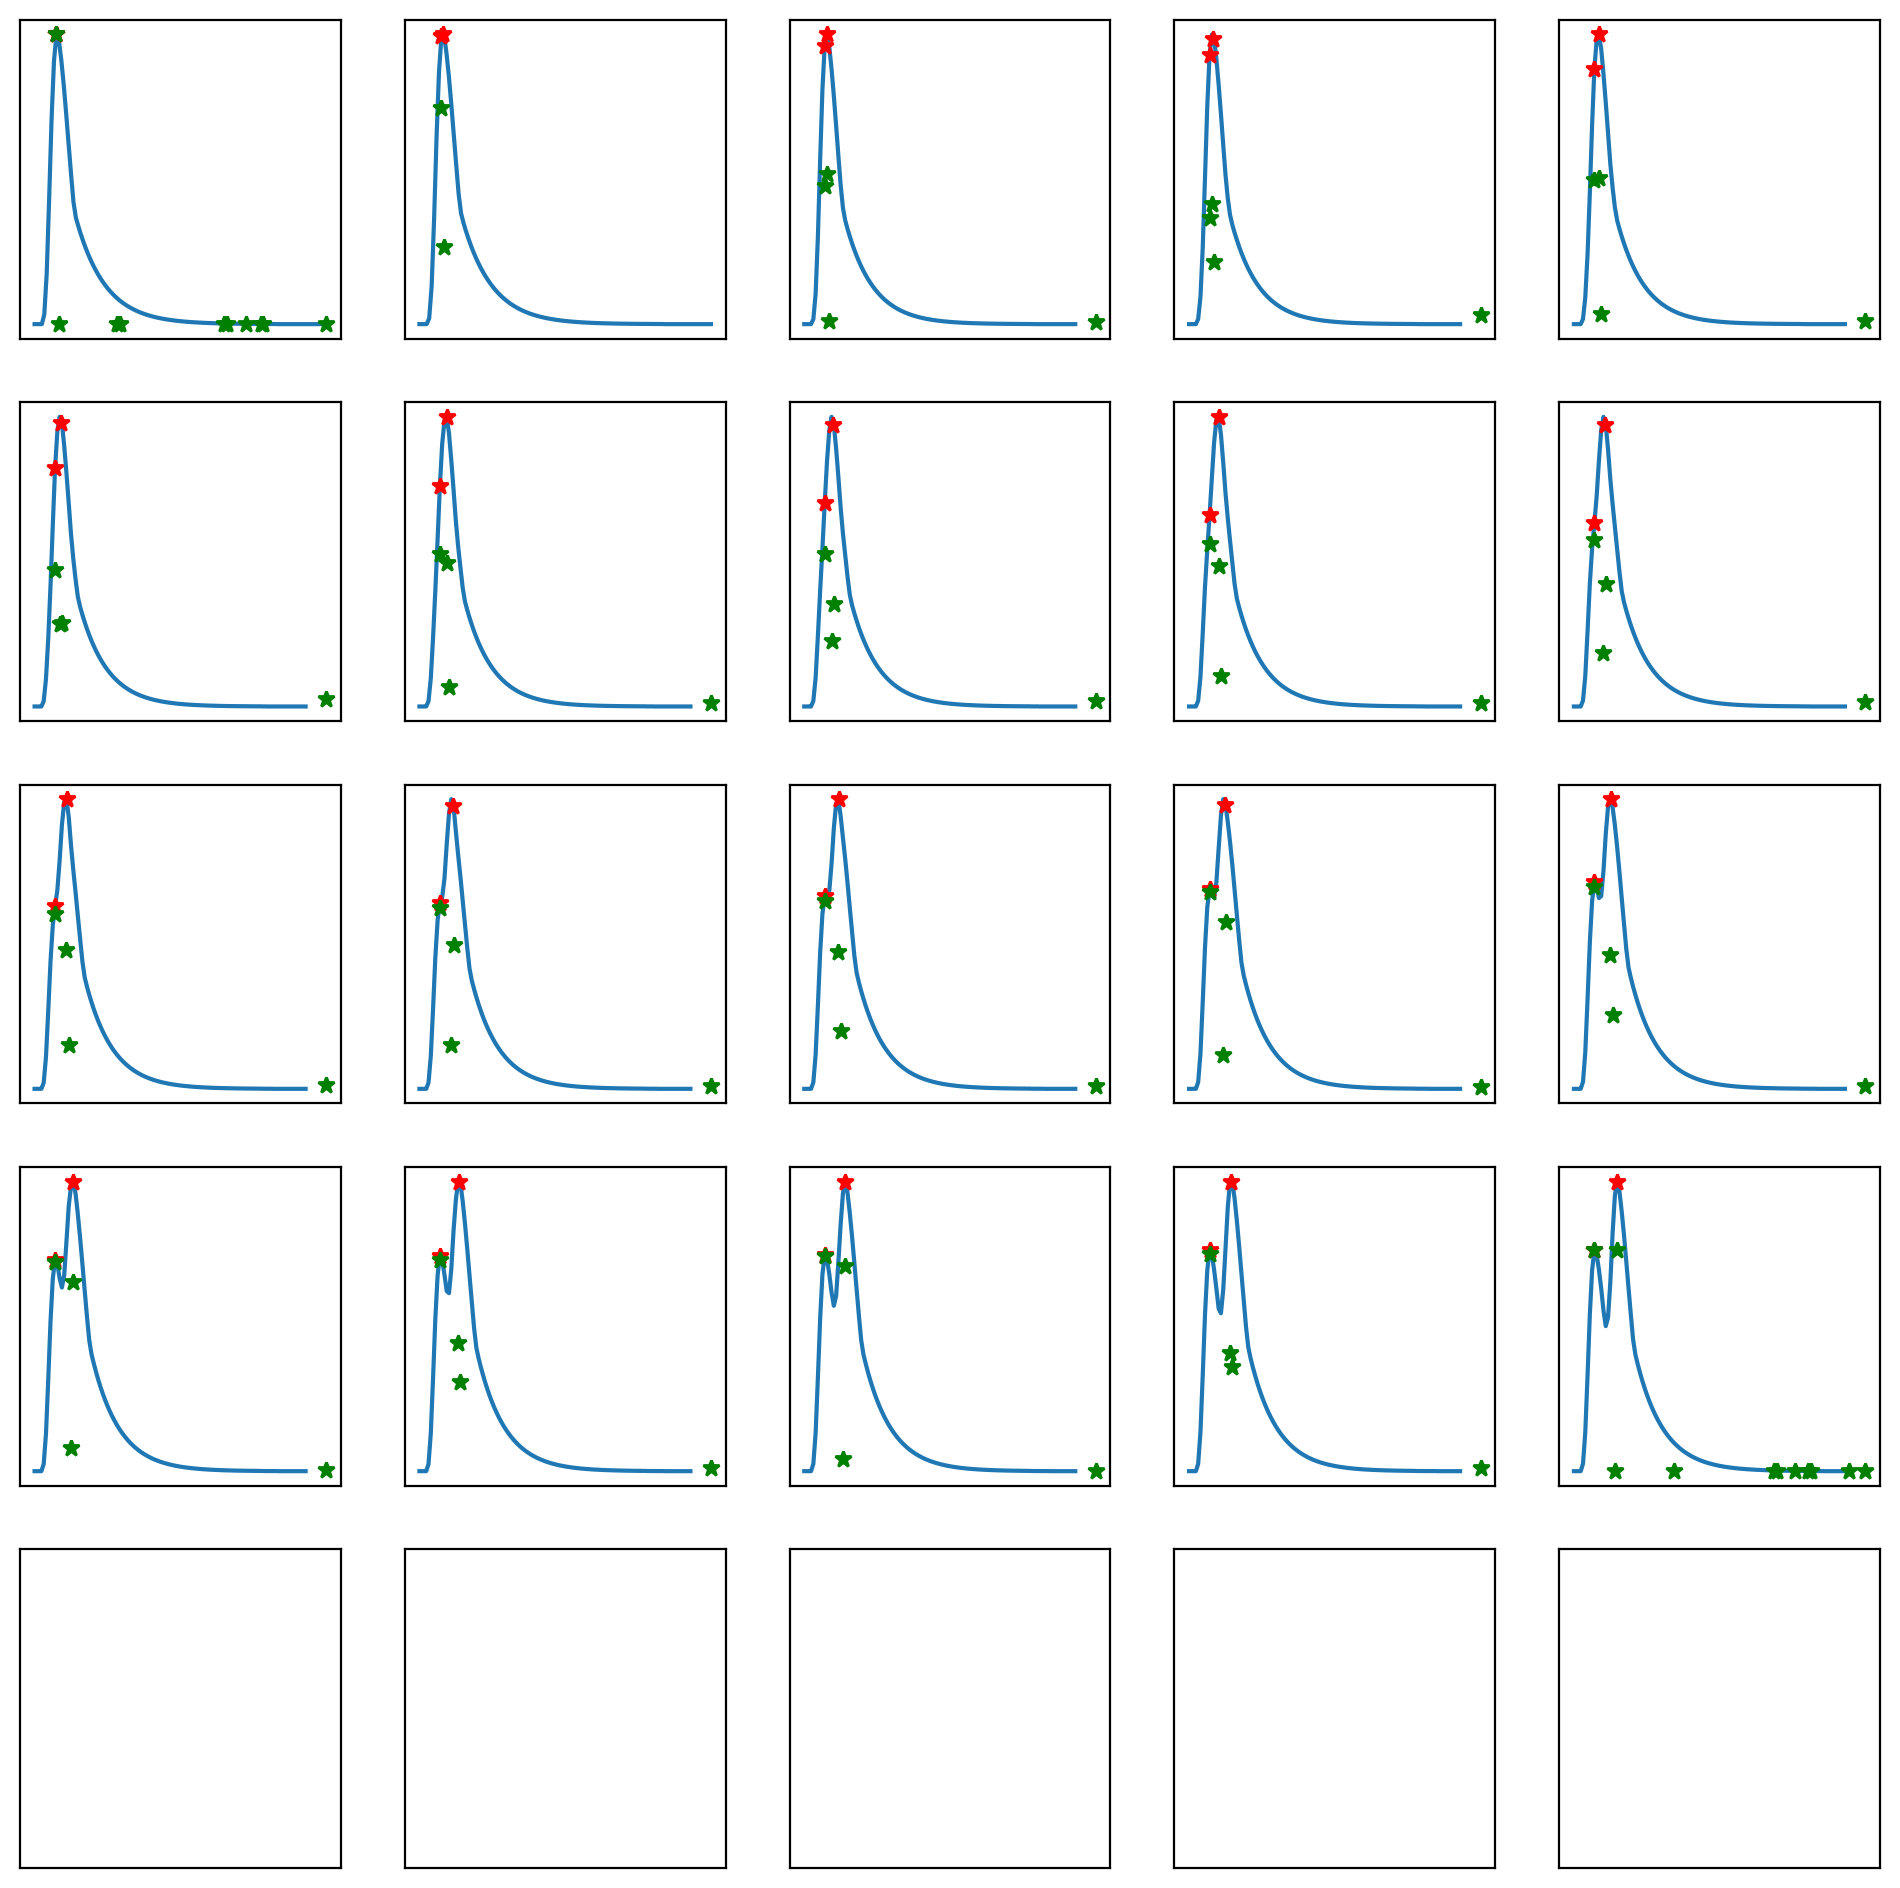

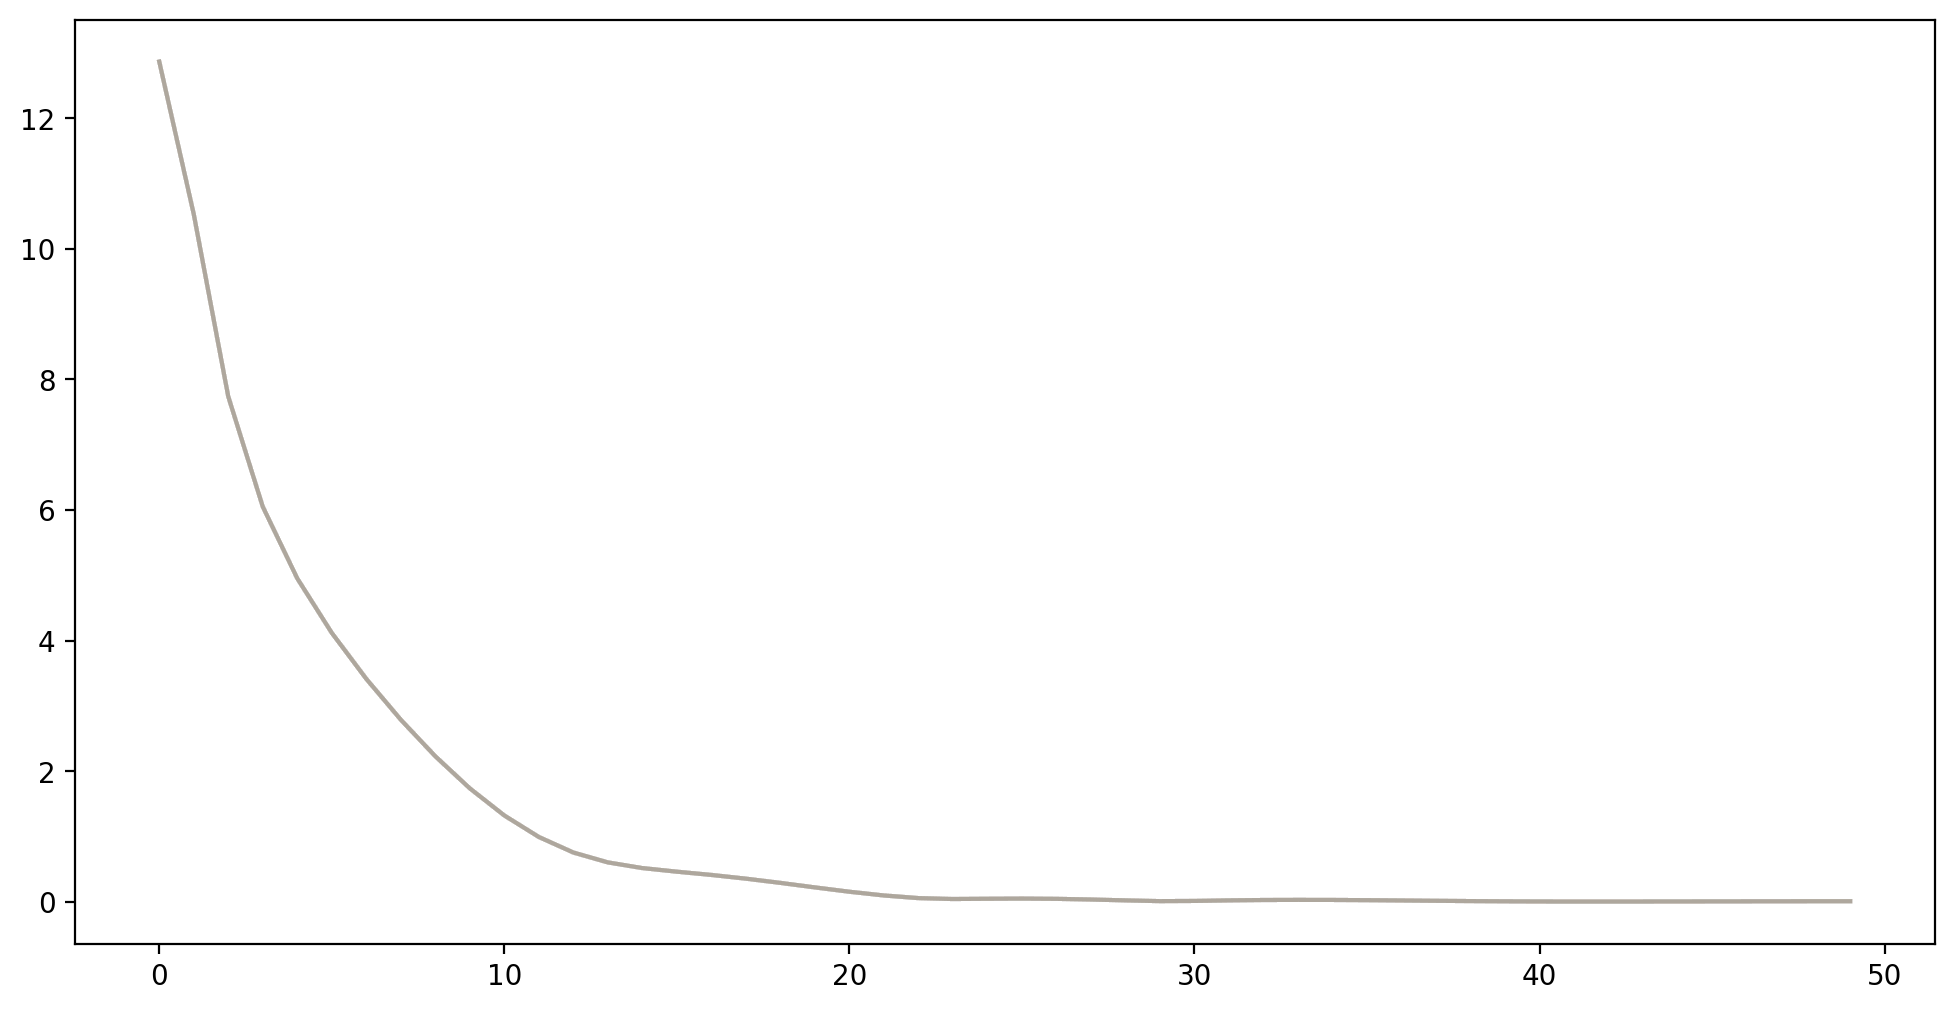

In [175]:
n = 20
sample_seperation = np.linspace(0, 10, n)

m = int(np.ceil(np.sqrt(sample_seperation.size)))

fig, axes = plt.subplots(m,m, figsize=(12,12), dpi=200)
for axis in axes.ravel().tolist():
    axis.set_xticks([])
    axis.set_yticks([])
    
fig2, axes2 = plt.subplots(1,1, figsize=(12, 6), dpi=200)

_, kernel = nai_pulse(1)
kernel = kernel[:-1]

kernel_fft_z = scipy.fft.fft(kernel)

for i, ds in enumerate(sample_seperation.tolist()):
    trace = np.zeros(kernel.size + 20)
    trace[:kernel.size] = trace[:kernel.size] + kernel
    
    intshift = int(ds)
    complex_shifted_ifft_shifted = sample_shift_to_phase_shift(sample_shift=ds-intshift, kernel_fft_z=kernel_fft_z, return_extra=False)
    td_shifted = scipy.fft.ifft(complex_shifted_ifft_shifted)
    td_shifted = np.abs(td_shifted)
    trace[intshift:td_shifted.size + intshift] = trace[intshift:td_shifted.size + intshift] + td_shifted
    
    axis = axes.ravel()[i]
    axis.plot(trace)
    
    peak_offset = np.argmax(kernel)
    axis.plot(peak_offset, trace[peak_offset], 'r*')
    axis.plot(peak_offset + + ds, trace[peak_offset + np.round(ds).astype(int)], 'r*')
    
    volts, indeces = threshold_nnlsr_deconvolve(trace, kernel)
    axis.plot(indeces + peak_offset, volts, 'g*')
    
    fd = np.abs(complex_shifted_ifft_shifted)[:complex_shifted_ifft_shifted.size//2]
    axes2.plot(fd, label=ds, alpha=.05)
    

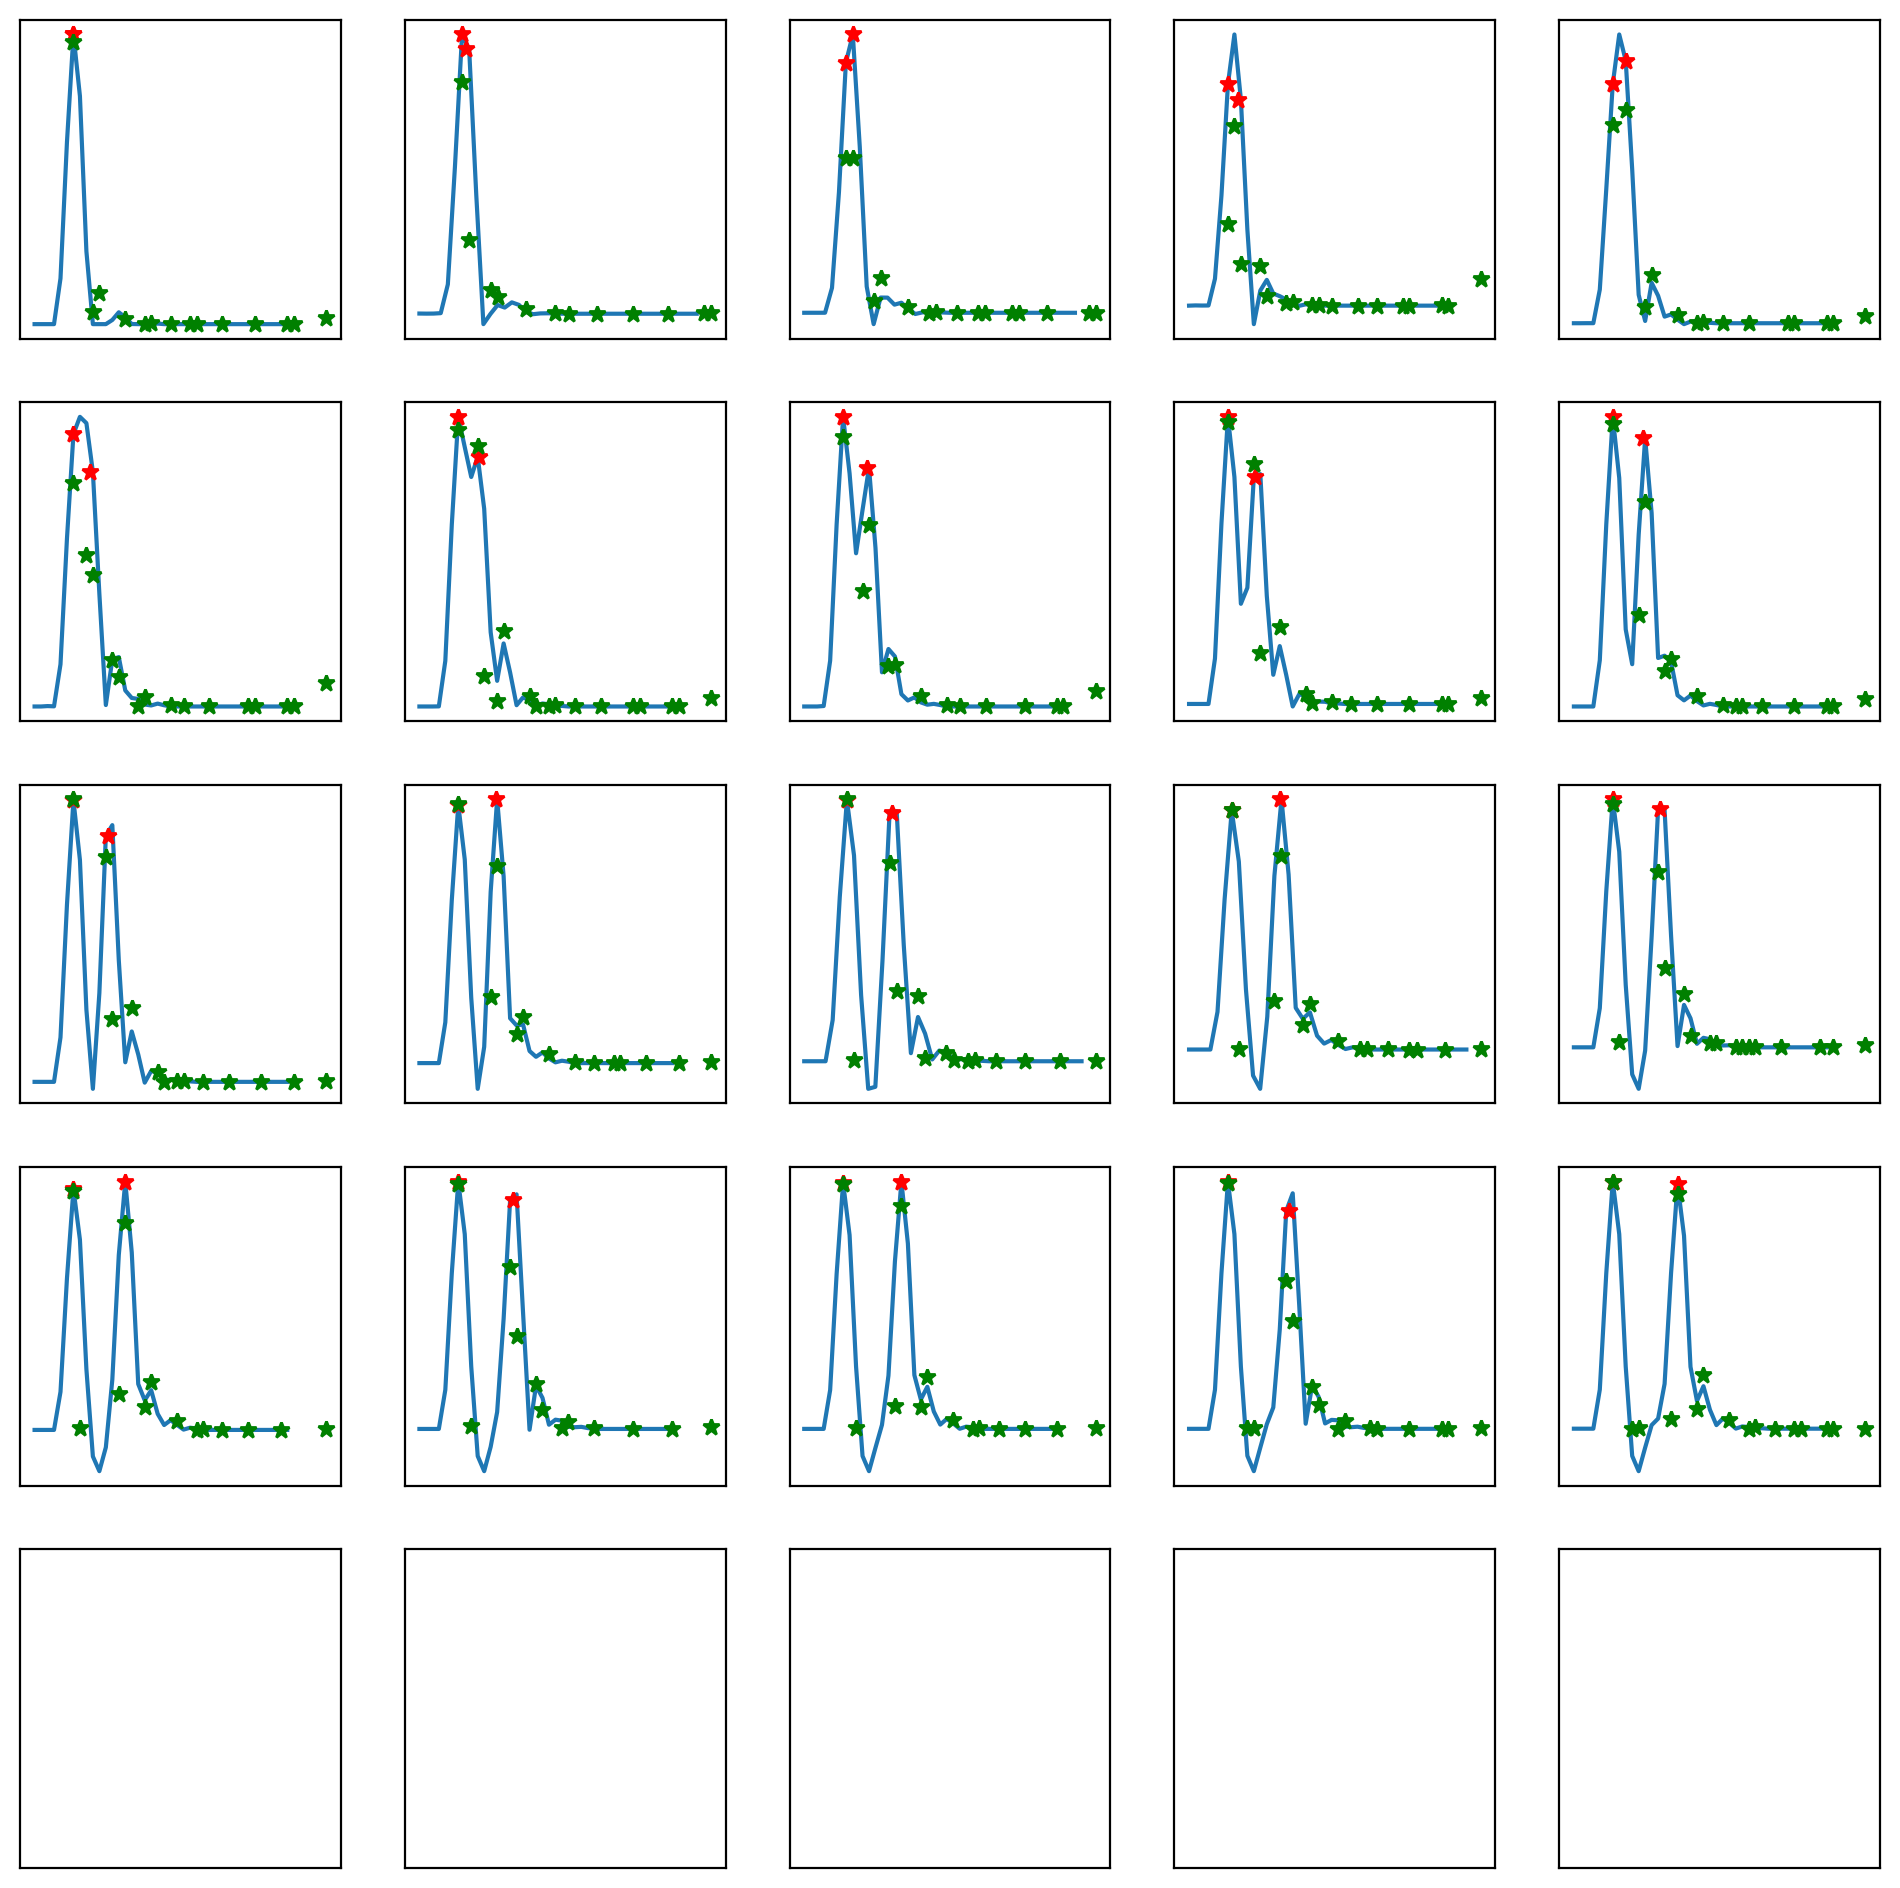

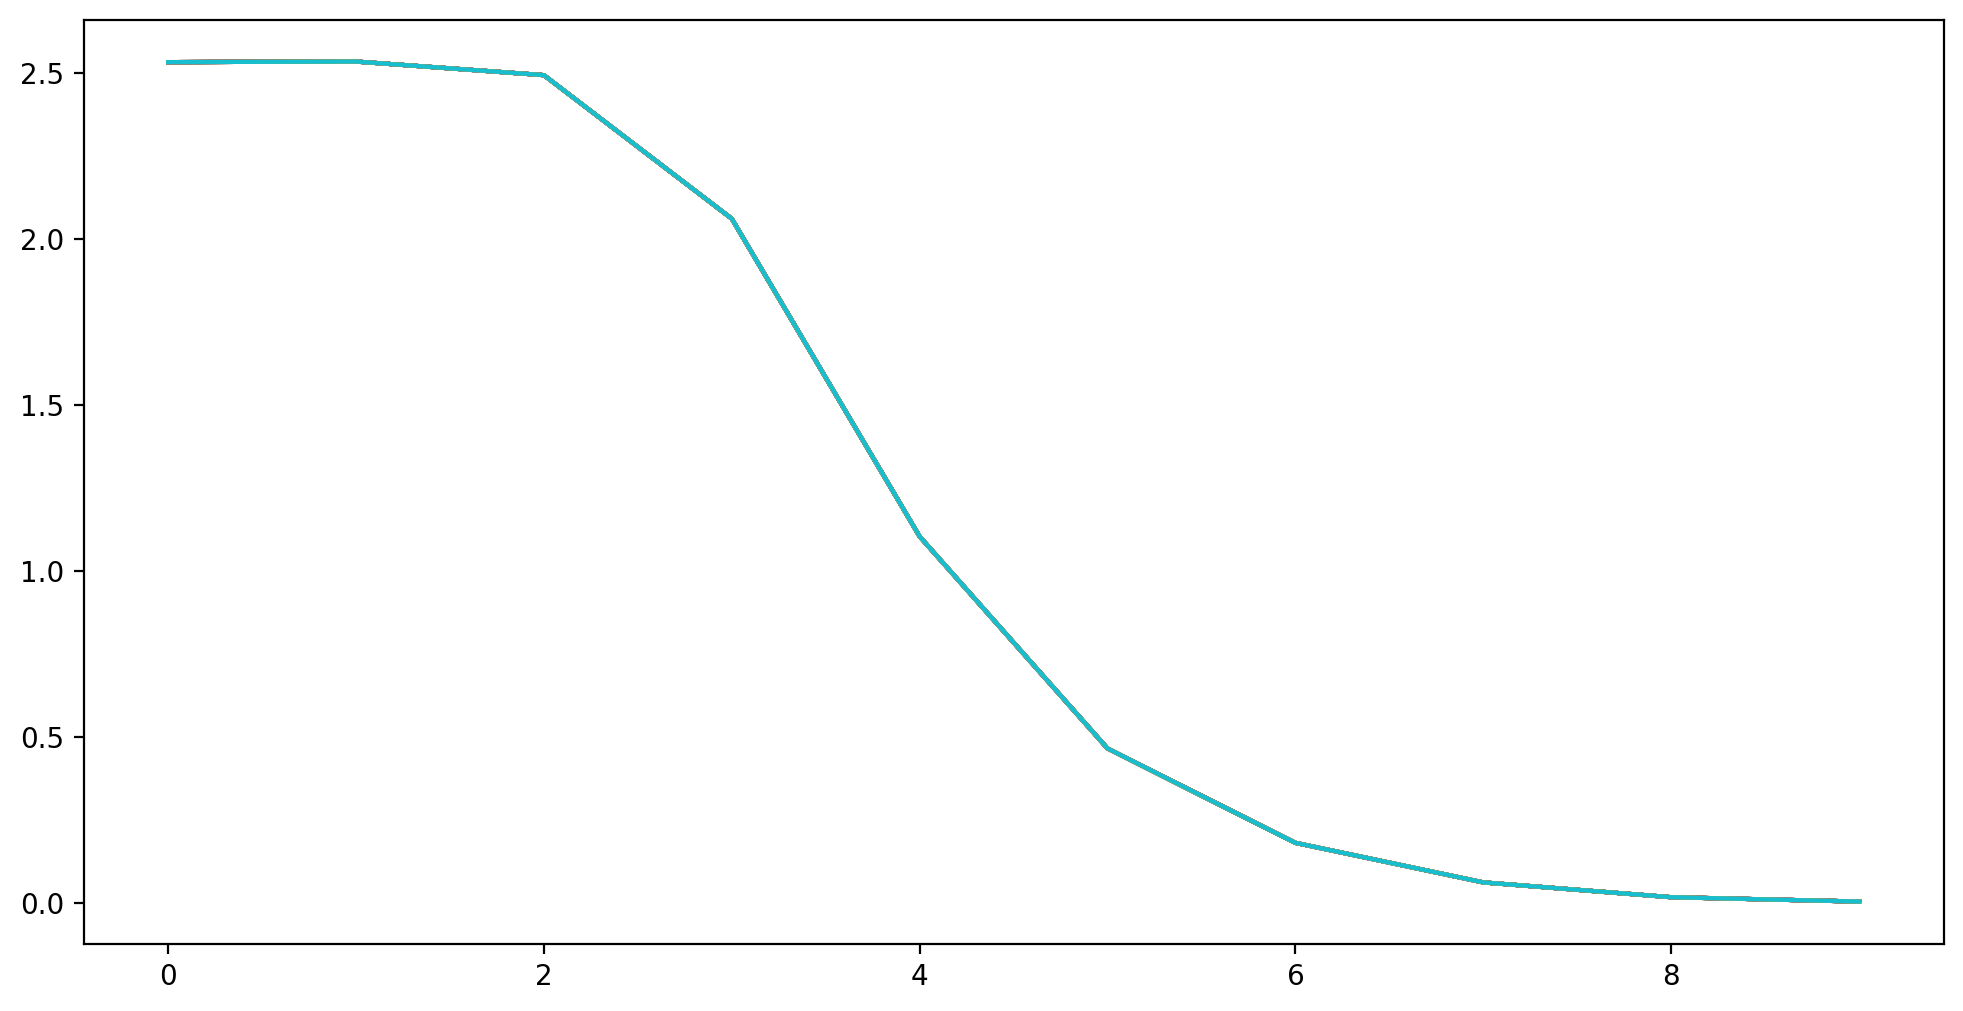

In [176]:
n = 20
sample_seperation = np.linspace(0, 10, n)

m = int(np.ceil(np.sqrt(sample_seperation.size)))

fig, axes = plt.subplots(m,m, figsize=(12,12), dpi=200)
for axis in axes.ravel().tolist():
    axis.set_xticks([])
    axis.set_yticks([])
    
fig2, axes2 = plt.subplots(1,1, figsize=(12, 6), dpi=200)

_, kernel = plastic_pulse(1)

kernel_fft_z = scipy.fft.fft(kernel)

for i, ds in enumerate(sample_seperation.tolist()):
    trace = np.zeros(kernel.size + 20)
    trace[:kernel.size] = trace[:kernel.size] + kernel
    
    intshift = int(ds)
    complex_shifted_ifft_shifted = sample_shift_to_phase_shift(sample_shift=ds-intshift, kernel_fft_z=kernel_fft_z, return_extra=False)
    td_shifted = scipy.fft.ifft(complex_shifted_ifft_shifted)
    td_shifted = np.abs(td_shifted)
    trace[intshift:td_shifted.size + intshift] = trace[intshift:td_shifted.size + intshift] + td_shifted
    
    axis = axes.ravel()[i]
    axis.plot(trace)
    
    peak_offset = np.argmax(kernel)
    axis.plot(peak_offset, trace[peak_offset], 'r*')
    axis.plot(peak_offset + + ds, trace[peak_offset + np.round(ds).astype(int)], 'r*')
    
    volts, indeces = threshold_nnlsr_deconvolve(trace, kernel)
    axis.plot(indeces + peak_offset, volts, 'g*')
    
    fd = np.abs(complex_shifted_ifft_shifted)[:complex_shifted_ifft_shifted.size//2]
    axes2.plot(fd, label = ds)
    

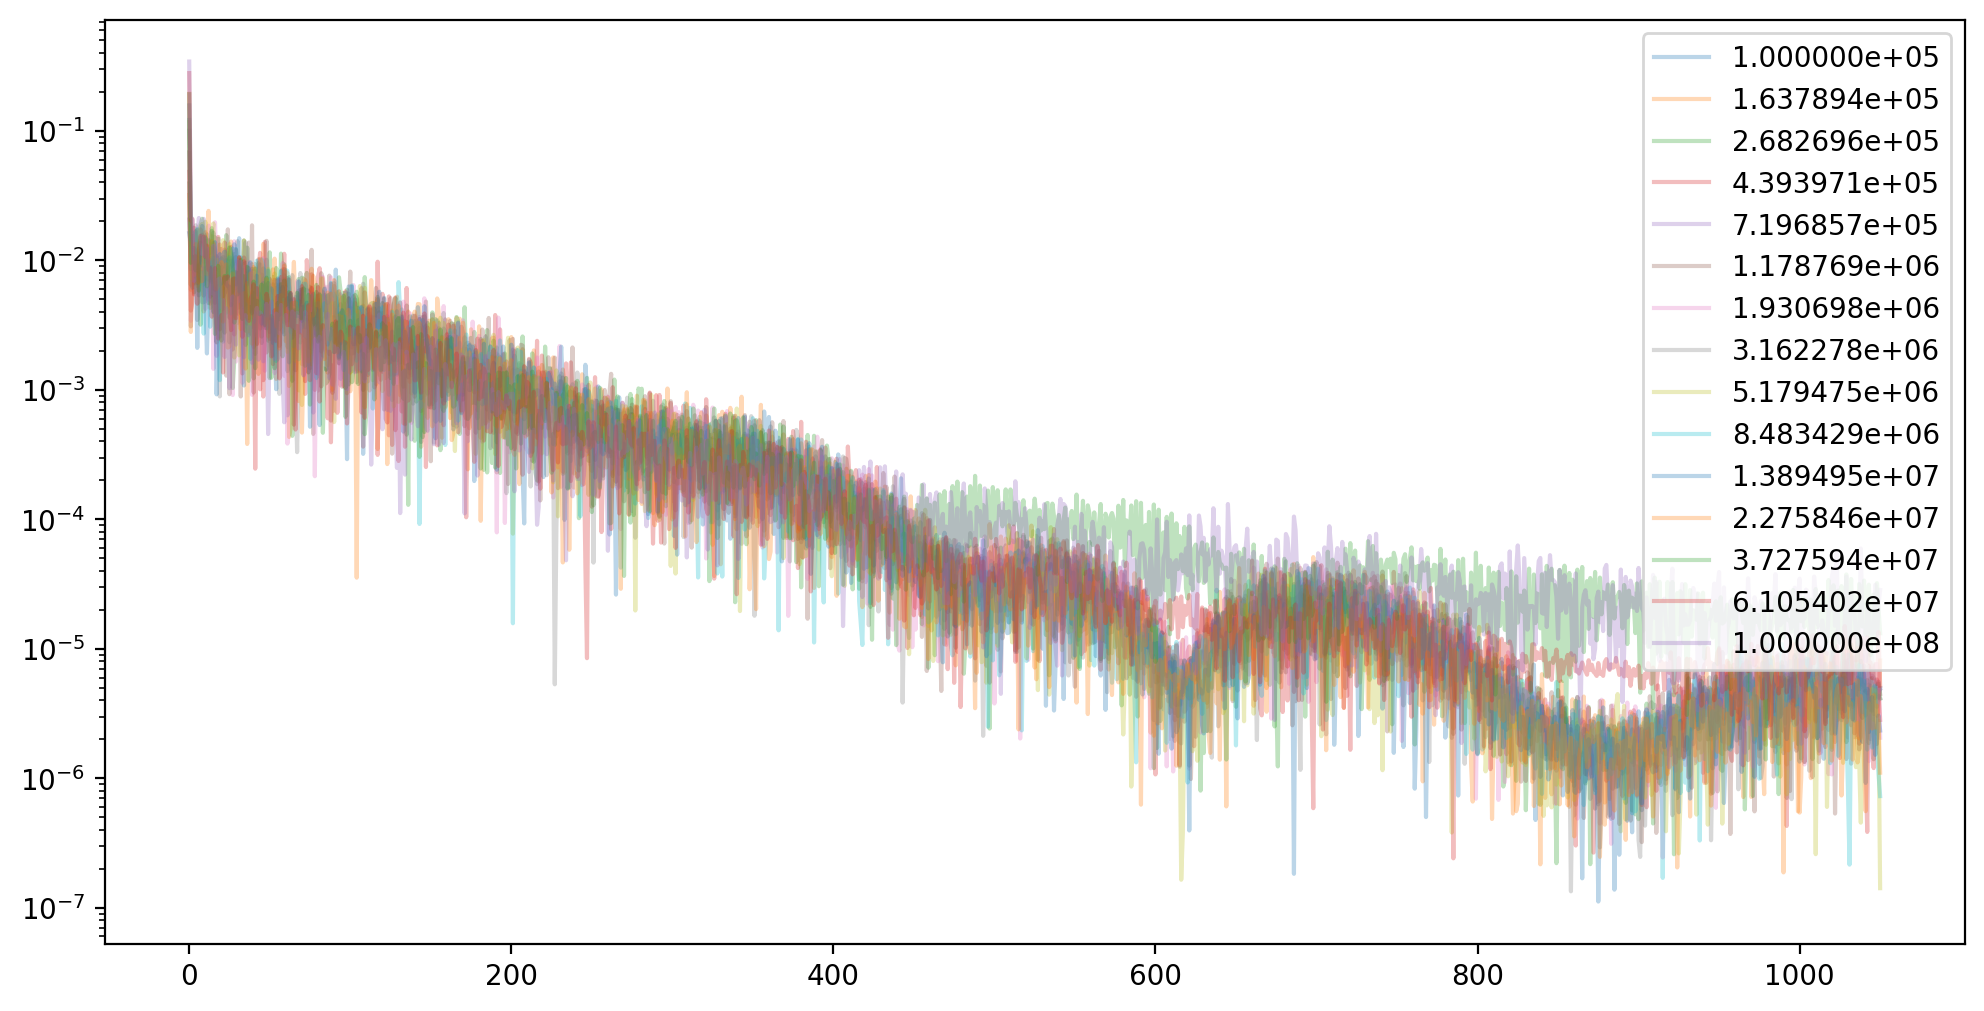

In [177]:
sensor_type = 'NaI'
assert sensor_type in ['NaI', 'plastic']

# Trace Parameters
keV_per_area = .147
mV_per_ADC = 1000/4096
baseline = 0 # mV
basenoise= 0 # mV
bits = 24
clip = 1000 # mV
fs = 40E6 # new HERA sampling rate
total_time = 5E-5
# for Lognormal traces
fwhm = 50 #50.0 #fwhm of the total TGF count distribution in units microseconds
mean = .007, #.7 #mean of the TGF trace distribution
std = 0 #.5 #determines the amount of assymetry in the TGF trace distribution

countrates = np.logspace(5,8,15)

if sensor_type == 'plastic':
    _, kernel = plastic_pulse(1)
    spectrum = np.loadtxt('../original/LgPl_Response', usecols=(1), dtype=float)
    bins = 1E3 * np.loadtxt('../original/LgPl_Response', usecols=(0), dtype=float)  # in kev
else:
    _, kernel = nai_pulse(1, 101)
    spectrum = np.loadtxt('../original/NaI_Response', usecols=(1), dtype=float)
    bins = 1E3 * np.loadtxt('../original/NaI_Response', usecols=(0), dtype=float)  # in kev

common_trace_kwargs = {
    'trace_type': 'constant',
    'keV_per_area' : keV_per_area,
    'mV_per_ADC' : mV_per_ADC,
    'baseline' : baseline, # mV
    'basenoise': basenoise, # mV
    'bits' : bits,
    'clip_magnitude' : clip, # mV
    'fs' : fs, # new HERA sampling rate
    'total_time' : total_time,
    'spectrum_hist': spectrum,
    'detector_response_kernel': kernel,
    'spectrum_bin_energies':bins,
    # for Lognormal traces
    'lognormal_fwhm' : fwhm, #50.0 #fwhm of the total TGF count distribution in units microseconds
    'lognormal_mean' : mean, #.7 #mean of the TGF trace distribution
    'lognormal_std' : std, #.5 #determines the amount of assymetry in the TGF trace distribution
    'return_object':True
}

fig, axes = plt.subplots(1,1, figsize=(12, 6), dpi=200)
axes.set_yscale('log')

for rate in countrates.tolist():
    kwargs_copy = deepcopy(common_trace_kwargs)
    kwargs_copy['count_rate'] = rate
    out = continuous_time_trace(**kwargs_copy)
    # axes.plot(out.trace)
    
    fd = scipy.fft.rfft(out.trace)
    fd = np.abs(fd[:-1])
    # fd = fd / np.max(fd)
    fd = fd / np.sum(fd)
    axes.plot(fd, alpha=.3, label='{:3e}'.format(rate))
    
axes.legend()

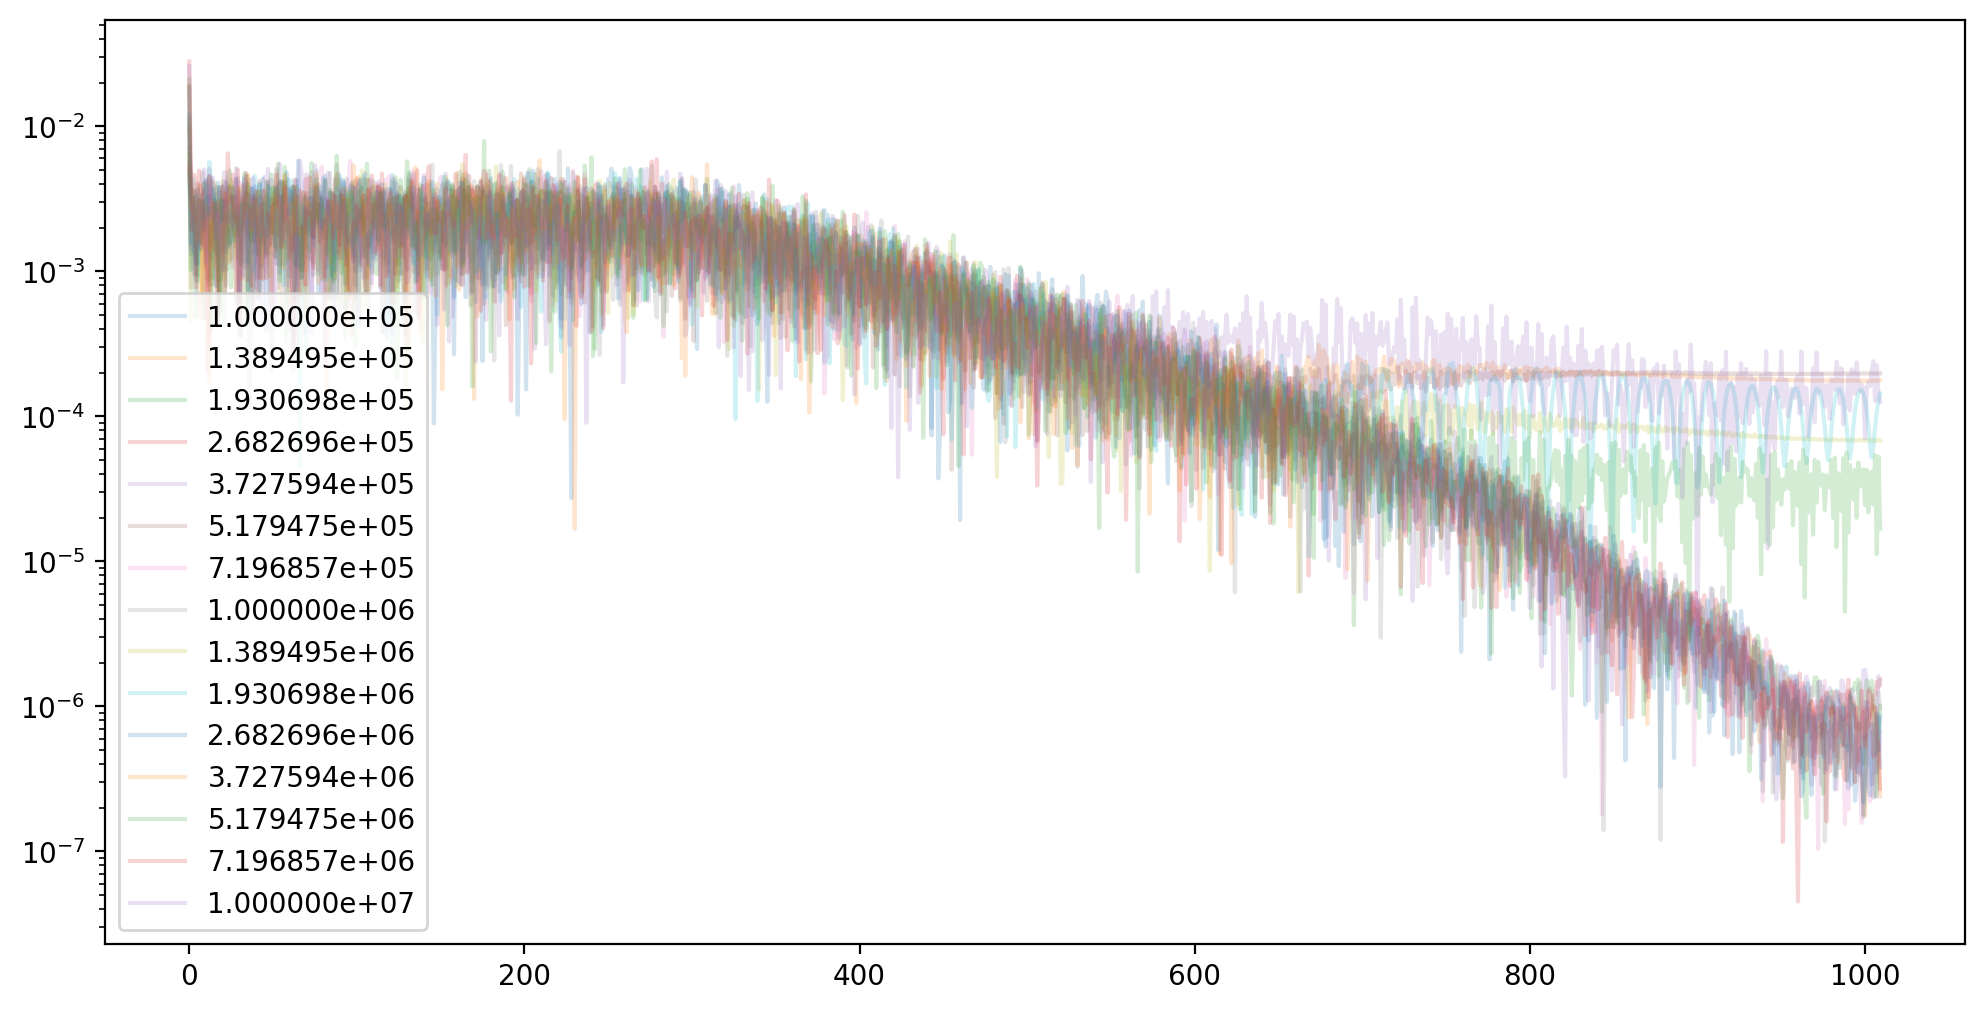

In [180]:
sensor_type = 'plastic'
assert sensor_type in ['NaI', 'plastic']

# Trace Parameters
keV_per_area = .147
mV_per_ADC = 1000/4096
baseline = 0 # mV
basenoise= 0 # mV
bits = 24
clip = 1000 # mV
fs = 40E6 # new HERA sampling rate
total_time = 5E-5
# for Lognormal traces
fwhm = 50 #50.0 #fwhm of the total TGF count distribution in units microseconds
mean = .007, #.7 #mean of the TGF trace distribution
std = 0 #.5 #determines the amount of assymetry in the TGF trace distribution

countrates = np.logspace(5,7,15)

if sensor_type == 'plastic':
    _, kernel = plastic_pulse(1)
    spectrum = np.loadtxt('../original/LgPl_Response', usecols=(1), dtype=float)
    bins = 1E3 * np.loadtxt('../original/LgPl_Response', usecols=(0), dtype=float)  # in kev
else:
    _, kernel = nai_pulse(1, 101)
    spectrum = np.loadtxt('../original/NaI_Response', usecols=(1), dtype=float)
    bins = 1E3 * np.loadtxt('../original/NaI_Response', usecols=(0), dtype=float)  # in kev

common_trace_kwargs = {
    'trace_type': 'constant',
    'keV_per_area' : keV_per_area,
    'mV_per_ADC' : mV_per_ADC,
    'baseline' : baseline, # mV
    'basenoise': basenoise, # mV
    'bits' : bits,
    'clip_magnitude' : clip, # mV
    'fs' : fs, # new HERA sampling rate
    'total_time' : total_time,
    'spectrum_hist': spectrum,
    'detector_response_kernel': kernel,
    'spectrum_bin_energies':bins,
    # for Lognormal traces
    'lognormal_fwhm' : fwhm, #50.0 #fwhm of the total TGF count distribution in units microseconds
    'lognormal_mean' : mean, #.7 #mean of the TGF trace distribution
    'lognormal_std' : std, #.5 #determines the amount of assymetry in the TGF trace distribution
    'return_object':True
}

fig, axes = plt.subplots(1,1, figsize=(12, 6), dpi=200)
axes.set_yscale('log')

for rate in countrates.tolist():
    kwargs_copy = deepcopy(common_trace_kwargs)
    kwargs_copy['count_rate'] = rate
    out = continuous_time_trace(**kwargs_copy)
    # axes.plot(out.trace)
    
    fd = scipy.fft.rfft(out.trace)
    fd = np.abs(fd[:-1])
    # fd = fd / np.max(fd)
    fd = fd / np.sum(fd)
    axes.plot(fd, alpha=.2, label='{:3e}'.format(rate))
    
axes.legend()